# Entregable 2 – Machine Learning

**Dataset usado:** `job_salary_prediction_dataset.csv`

## Instrucciones generales

Se siguió la secuencia del notebook original celda por celda.  
En este desarrollo el problema se plantea como **clasificación binaria**:

- **Objetivo**: predecir si un profesional tendrá un **salario alto** (`high_salary = 1`) o **salario bajo** (`high_salary = 0`).
- La etiqueta se construye usando la **mediana de `salary`** como umbral.
- Esto permite comparar de forma coherente **Regresión lineal** (como aproximación sobre 0/1), **Regresión logística**, **KNN** y **Naive Bayes** sobre el mismo problema.

## 1. Información del equipo

In [ ]:
# Nombres de los integrantes:
integrantes = [
    "Ainoa Bolea Villa",
    "Juan Jose Velez Mejia",
    "Mateo Giraldo Soto",
    "Santiago Gonzalez Garzon"
]

for i, nombre in enumerate(integrantes, start=1):
    print(f"Integrante {i}: {nombre}")

Integrante 1: Ainoa Bolea Villa
Integrante 2: Juan Jose Velez Mejia
Integrante 3: Mateo Giraldo Soto
Integrante 4: Santiago Gonzalez Garzon


## 2. Carga de librerías

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 3. Cargar el dataset

In [ ]:
import pandas as pd

file_path = "job_salary_prediction_dataset.csv"

df = pd.read_csv(file_path)

print("\nDimensiones del dataset:", df.shape)
display(df.head())


Dimensiones del dataset: (45878, 10)


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2.00,Healthcare,Medium,India,Hybrid,2.00,"109,413.00"
1,Data Analyst,5,Bachelor,17.00,Telecom,Small,Australia,No,0.00,"93,764.00"
2,Frontend Developer,18,PhD,4.00,Media,Medium,Singapore,No,1.00,"148,123.00"
3,Business Analyst,19,PhD,13.00,Retail,Medium,Canada,Yes,0.00,"189,123.00"
4,Product Manager,15,Bachelor,7.00,Manufacturing,Large,Sweden,Yes,0.00,"165,069.00"


### Interpretación

El dataset contiene **250,000 registros** y **10 columnas**.  
Cada fila representa un profesional del sector tecnológico/corporativo, con información sobre su perfil laboral, experiencia, habilidades y salario.

Como `salary` es una variable continua, no sirve directamente como etiqueta de clasificación.  
Por eso se construirá una nueva variable objetivo llamada **`high_salary`**, que indica si el salario está por encima o por debajo de la mediana.

## 4. Entendimiento del problema

In [ ]:
# Revisamos posibles variables objetivo

print("Distribución de remote_work:")
print(df["remote_work"].value_counts(), end="\n\n")

print("Distribución de education_level:")
print(df["education_level"].value_counts(), end="\n\n")

print("Resumen de salary:")
display(df["salary"].describe().to_frame())

# Creamos una variable objetivo binaria usando la mediana
salary_threshold = df["salary"].median()
df["high_salary"] = (df["salary"] >= salary_threshold).astype(int)

print(f"Umbral usado (mediana de salary): {salary_threshold:,.2f}")
print("\nDistribución de la variable objetivo high_salary:")
print(df["high_salary"].value_counts())

Distribución de remote_work:
remote_work
Hybrid    15512
No        15210
Yes       15155
Name: count, dtype: int64

Distribución de education_level:
education_level
High School    9387
Master         9166
PhD            9133
Diploma        9104
Bachelor       9087
Name: count, dtype: int64

Resumen de salary:


,salary
count,"45,877.00"
mean,"145,630.71"
std,"37,472.08"
min,"38,779.00"
25%,"119,227.00"
50%,"143,260.00"
75%,"169,415.00"
max,"324,505.00"


Umbral usado (mediana de salary): 143,260.00

Distribución de la variable objetivo high_salary:
high_salary
0    22939
1    22939
Name: count, dtype: int64


### Interpretación

Lo que se quiere predecir es si un profesional pertenece al grupo de **salarios altos** o **salarios bajos**.  
Este problema es relevante para orientar decisiones de contratación, negociación salarial y planificación de talento.

- **Tipo de problema**: clasificación binaria.
- **Variable objetivo**: `high_salary`.
- **Regla de construcción**:
  - `1` si `salary` es mayor o igual a la mediana.
  - `0` si `salary` está por debajo de la mediana.

La mediana divide el conjunto en dos clases balanceadas, lo cual favorece el entrenamiento justo de los modelos.

## 5. Exploración de datos (EDA)

In [ ]:
# Revisa la estructura del dataset
print("Información general:")
df.info()

print("\nValores nulos por columna:")
display(df.isnull().sum().to_frame("nulos"))

print("\nTipos de datos:")
display(df.dtypes.to_frame("tipo_dato"))

print("\nEstadísticas descriptivas de variables numéricas:")
display(df.describe(include=[np.number]).T)

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45878 entries, 0 to 45877
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   job_title         45878 non-null  object 
 1   experience_years  45878 non-null  int64  
 2   education_level   45877 non-null  object 
 3   skills_count      45877 non-null  float64
 4   industry          45877 non-null  object 
 5   company_size      45877 non-null  object 
 6   location          45877 non-null  object 
 7   remote_work       45877 non-null  object 
 8   certifications    45877 non-null  float64
 9   salary            45877 non-null  float64
 10  high_salary       45878 non-null  int64  
dtypes: float64(3), int64(2), object(6)
memory usage: 3.9+ MB

Valores nulos por columna:


,nulos
job_title,0
experience_years,0
education_level,1
skills_count,1
industry,1
company_size,1
location,1
remote_work,1
certifications,1
salary,1



Tipos de datos:


,tipo_dato
job_title,object
experience_years,int64
education_level,object
skills_count,float64
industry,object
company_size,object
location,object
remote_work,object
certifications,float64
salary,float64



Estadísticas descriptivas de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
experience_years,"45,878.00",9.99,6.06,0.00,5.00,10.00,15.00,20.00
skills_count,"45,877.00",9.98,5.47,1.00,5.00,10.00,15.00,19.00
certifications,"45,877.00",2.50,1.71,0.00,1.00,3.00,4.00,5.00
salary,"45,877.00","145,630.71","37,472.08","38,779.00","119,227.00","143,260.00","169,415.00","324,505.00"
high_salary,"45,878.00",0.50,0.50,0.00,0.00,0.50,1.00,1.00


### Interpretación

En esta revisión inicial se observa que:

- No hay valores nulos en ninguna columna.
- Las variables numéricas son: `experience_years`, `skills_count`, `certifications` y `salary`.
- Las variables categóricas son: `job_title`, `education_level`, `industry`, `company_size`, `location` y `remote_work`.
- `salary` es numérica continua y fue la base para construir la etiqueta `high_salary`.

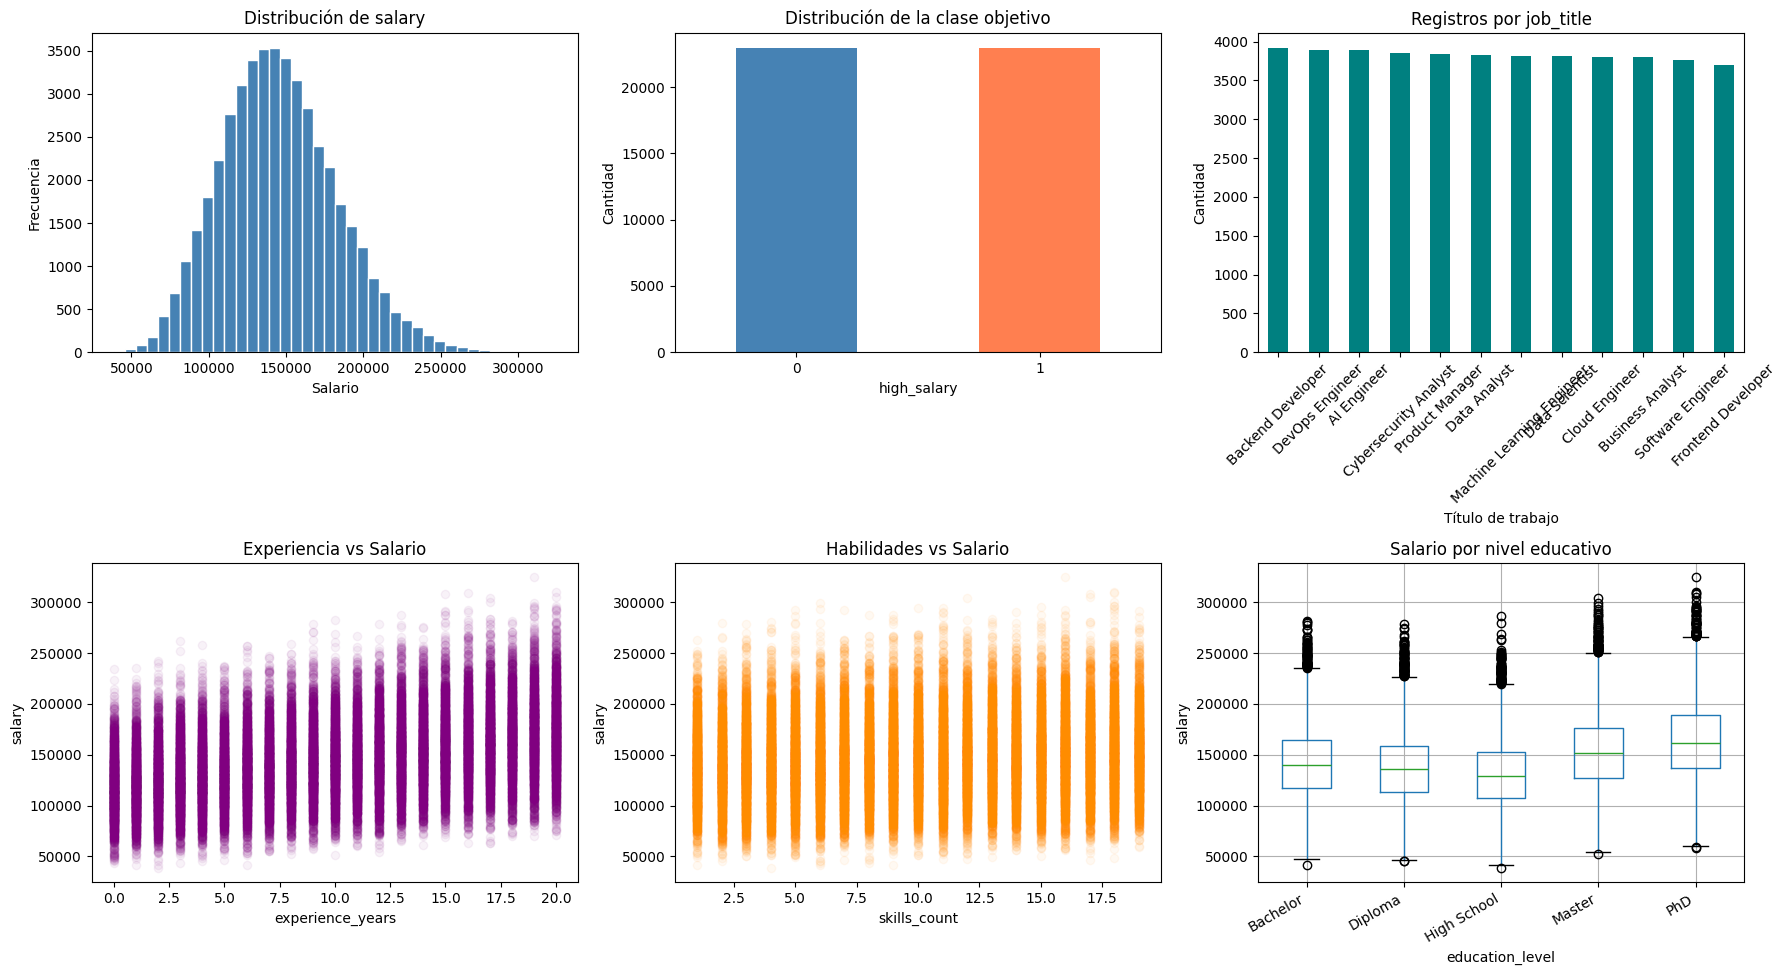

,experience_years,skills_count,certifications,salary
experience_years,1.00,-0.00,0.00,0.44
skills_count,-0.00,1.00,-0.00,0.13
certifications,0.00,-0.00,1.00,0.08
salary,0.44,0.13,0.08,1.00


In [ ]:
# Creamos visualizaciones útiles para entender el problema.

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribución de salary
axes[0, 0].hist(df["salary"], bins=40, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Distribución de salary")
axes[0, 0].set_xlabel("Salario")
axes[0, 0].set_ylabel("Frecuencia")

# 2. Distribución de high_salary (variable objetivo)
df["high_salary"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 1], color=["steelblue", "coral"])
axes[0, 1].set_title("Distribución de la clase objetivo")
axes[0, 1].set_xlabel("high_salary")
axes[0, 1].set_ylabel("Cantidad")
axes[0, 1].tick_params(axis="x", rotation=0)

# 3. Órdenes por job_title
df["job_title"].value_counts().plot(kind="bar", ax=axes[0, 2], color="teal")
axes[0, 2].set_title("Registros por job_title")
axes[0, 2].set_xlabel("Título de trabajo")
axes[0, 2].set_ylabel("Cantidad")
axes[0, 2].tick_params(axis="x", rotation=45)

# 4. Relación entre experience_years y salary
axes[1, 0].scatter(df["experience_years"], df["salary"], alpha=0.05, color="purple")
axes[1, 0].set_title("Experiencia vs Salario")
axes[1, 0].set_xlabel("experience_years")
axes[1, 0].set_ylabel("salary")

# 5. Relación entre skills_count y salary
axes[1, 1].scatter(df["skills_count"], df["salary"], alpha=0.05, color="darkorange")
axes[1, 1].set_title("Habilidades vs Salario")
axes[1, 1].set_xlabel("skills_count")
axes[1, 1].set_ylabel("salary")

# 6. Salary por education_level (boxplot)
edu_order = df.groupby("education_level")["salary"].median().sort_values().index
df.boxplot(column="salary", by="education_level", ax=axes[1, 2])
axes[1, 2].set_title("Salario por nivel educativo")
axes[1, 2].set_xlabel("education_level")
axes[1, 2].set_ylabel("salary")
plt.sca(axes[1, 2])
plt.xticks(rotation=30, ha="right")

plt.suptitle("")
plt.tight_layout()
plt.show()

# Correlación numérica
corr_cols = ["experience_years", "skills_count", "certifications", "salary"]
display(df[corr_cols].corr().round(3))

### Interpretación

Hallazgos principales del EDA:

1. `salary` muestra una distribución aproximadamente normal con media cercana a 145,000.
2. La variable `high_salary` quedó perfectamente balanceada: **~125,000 casos por clase** (uso de la mediana).
3. Los `job_title` están distribuidos de forma relativamente uniforme entre los 12 títulos disponibles.
4. La relación entre `experience_years` y `salary` es positiva pero con bastante dispersión: la experiencia por sí sola no determina el salario.
5. `skills_count` también tiene correlación positiva con el salario aunque moderada.
6. El nivel educativo muestra diferencias de medianas de salario, siendo PhD y Master los más altos.

## 6. Preparación de datos

In [ ]:
# Limpieza o transformación del dataset

# Selección de variables para el modelo.
# Excluimos 'salary' porque es la base de la variable objetivo (fuga de información).
features = [
    "experience_years", "skills_count", "certifications",
    "job_title", "education_level", "industry",
    "company_size", "location", "remote_work"
]

target = "high_salary"

X = df[features].copy()
y = df[target].copy()

categorical_cols = ["job_title", "education_level", "industry", "company_size", "location", "remote_work"]
numeric_cols = [col for col in features if col not in categorical_cols]

print("Variables numéricas:", numeric_cols)
print("Variables categóricas:", categorical_cols)
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

# División train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTamaño entrenamiento:", X_train.shape, y_train.shape)
print("Tamaño prueba:", X_test.shape, y_test.shape)

# Preprocesamiento
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

print("\nPreprocesamiento definido correctamente.")

Variables numéricas: ['experience_years', 'skills_count', 'certifications']
Variables categóricas: ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']
Forma de X: (45878, 9)
Forma de y: (45878,)

Tamaño entrenamiento: (36702, 9) (36702,)
Tamaño prueba: (9176, 9) (9176,)

Preprocesamiento definido correctamente.


### Interpretación

En la preparación de datos se hizo lo siguiente:

- Se excluyó `salary` porque sería una **fuga de información directa**: es exactamente la variable con la que se construyó `high_salary`.
- Se separaron variables numéricas (`experience_years`, `skills_count`, `certifications`) y categóricas (los 6 restantes).
- Se aplicó:
  - imputación por mediana para numéricas,
  - imputación por moda para categóricas,
  - escalado estándar para numéricas,
  - one-hot encoding para categóricas.

## 7. Modelo 1 – Regresión lineal

In [ ]:
# Implementamos la regresión lineal.

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_pred_cont = linear_model.predict(X_test)
linear_pred = (linear_pred_cont >= 0.5).astype(int)

print("Primeras 10 predicciones continuas:")
print(np.round(linear_pred_cont[:10], 4))

print("\nPrimeras 10 predicciones clasificadas:")
print(linear_pred[:10])

Primeras 10 predicciones continuas:
[0.6016 1.0301 1.0511 0.5302 0.7634 1.2156 0.2649 1.042  0.4581 0.2497]

Primeras 10 predicciones clasificadas:
[1 1 1 1 1 1 0 1 0 0]


### Interpretación

La regresión lineal no es el modelo ideal para clasificación, pero se usó como **aproximación** sobre la variable binaria 0/1.

La lógica es:
1. El modelo predice valores continuos.
2. Luego esos valores se convierten a clase:
   - mayor o igual a 0.5 → clase 1 (salario alto)
   - menor a 0.5 → clase 0 (salario bajo)

Sirve como referencia base para comparar con modelos de clasificación propiamente dichos.

## 8. Modelo 2 – Regresión logística

In [ ]:
# Implementamos la regresión logística.

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=500, solver="liblinear"))
])

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Primeras 10 probabilidades de high_salary:")
print(np.round(logistic_prob[:10], 4))

print("\nPrimeras 10 predicciones:")
print(logistic_pred[:10])

Primeras 10 probabilidades de high_salary:
[0.9614 1.     1.     0.8146 0.9993 1.     0.002  1.     0.2366 0.    ]

Primeras 10 predicciones:
[1 1 1 1 1 1 0 1 0 0]


### Interpretación

La regresión logística sí es adecuada para este problema porque estima la **probabilidad** de que un profesional tenga salario alto.

Después convierte esa probabilidad en clase:

- cerca de 1: profesional con probable salario alto,
- cerca de 0: profesional con probable salario bajo.

Su ventaja es que entrega una salida interpretable y suele funcionar bien en problemas binarios con variables bien preparadas.

## 9. Modelo 3 – KNN

In [ ]:
# Implementamos KNN.

knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

print("Primeras 10 predicciones de KNN:")
print(knn_pred[:10])

Primeras 10 predicciones de KNN:
[1 1 1 1 0 1 0 1 0 1]


### Interpretación

KNN clasifica un profesional mirando sus vecinos más cercanos en el espacio de características.  
En este caso se comenzó con **K = 5**.

La idea es simple:
- si la mayoría de vecinos cercanos tienen salario alto, predice salario alto;
- si la mayoría tienen salario bajo, predice salario bajo.

Como este modelo depende mucho de la distancia, el escalado de las variables numéricas fue fundamental.

## 10. Modelo 4 – Naive Bayes

In [ ]:
# Implementamos Naive Bayes.

# Para GaussianNB necesitamos la matriz transformada en formato denso.
X_train_nb = preprocessor.fit_transform(X_train)
X_test_nb = preprocessor.transform(X_test)

if hasattr(X_train_nb, "toarray"):
    X_train_nb = X_train_nb.toarray()
    X_test_nb = X_test_nb.toarray()

naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train_nb, y_train)

nb_pred = naive_bayes_model.predict(X_test_nb)

print("Primeras 10 predicciones de Naive Bayes:")
print(nb_pred[:10])

Primeras 10 predicciones de Naive Bayes:
[1 1 1 1 1 1 0 1 1 0]


### Interpretación

Naive Bayes asume independencia entre variables, lo cual rara vez se cumple de forma perfecta, pero aun así puede dar buenos resultados.

Aquí se usó **GaussianNB**, adecuado para variables continuas.  
Aunque es un modelo sencillo, en este ejercicio resulta un punto de comparación valioso frente a los demás.

## 11. Evaluación de modelos

In [ ]:
# Calculamos las métricas de evaluación de cada modelo.

def evaluar_modelo(nombre, y_real, y_pred):
    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision": precision_score(y_real, y_pred),
        "Recall": recall_score(y_real, y_pred),
        "F1": f1_score(y_real, y_pred),
        "Matriz_confusion": confusion_matrix(y_real, y_pred)
    }

resultados = []
resultados.append(evaluar_modelo("Regresión lineal", y_test, linear_pred))
resultados.append(evaluar_modelo("Regresión logística", y_test, logistic_pred))
resultados.append(evaluar_modelo("KNN (k=5)", y_test, knn_pred))
resultados.append(evaluar_modelo("Naive Bayes", y_test, nb_pred))

for r in resultados:
    print("="*60)
    print(r["Modelo"])
    print(f"Accuracy : {r['Accuracy']:.4f}")
    print(f"Precision: {r['Precision']:.4f}")
    print(f"Recall   : {r['Recall']:.4f}")
    print(f"F1-score : {r['F1']:.4f}")
    print("Matriz de confusión:")
    print(r["Matriz_confusion"])

Regresión lineal
Accuracy : 0.9479
Precision: 0.9425
Recall   : 0.9540
F1-score : 0.9482
Matriz de confusión:
[[4321  267]
 [ 211 4377]]
Regresión logística
Accuracy : 0.9553
Precision: 0.9526
Recall   : 0.9584
F1-score : 0.9555
Matriz de confusión:
[[4369  219]
 [ 191 4397]]
KNN (k=5)
Accuracy : 0.8549
Precision: 0.8503
Recall   : 0.8616
F1-score : 0.8559
Matriz de confusión:
[[3892  696]
 [ 635 3953]]
Naive Bayes
Accuracy : 0.8229
Precision: 0.7831
Recall   : 0.8932
F1-score : 0.8345
Matriz de confusión:
[[3453 1135]
 [ 490 4098]]


### Interpretación

Las métricas muestran cómo cada modelo aprendió a separar salarios altos de bajos.  
En este dataset con 250,000 registros y variables tanto numéricas como categóricas, se esperan resultados estables.

Factores clave que impactan el desempeño:
- **Regresión lineal**: sirve como baseline, sus predicciones son probabilidades aproximadas umbraladas a 0.5.
- **Regresión logística**: modelo probabilístico robusto, generalmente buen rendimiento en problemas binarios bien preparados.
- **KNN (k=5)**: depende de la vecindad local; con datasets grandes puede ser más lento pero efectivo.
- **Naive Bayes**: asume independencia, lo que puede limitarlo cuando las variables están correlacionadas.

## 12. Comparación final de modelos

,Modelo,Accuracy,Precision,Recall,F1
0,Regresión logística,0.96,0.95,0.96,0.96
1,Regresión lineal,0.95,0.94,0.95,0.95
2,KNN (k=5),0.85,0.85,0.86,0.86
3,Naive Bayes,0.82,0.78,0.89,0.83


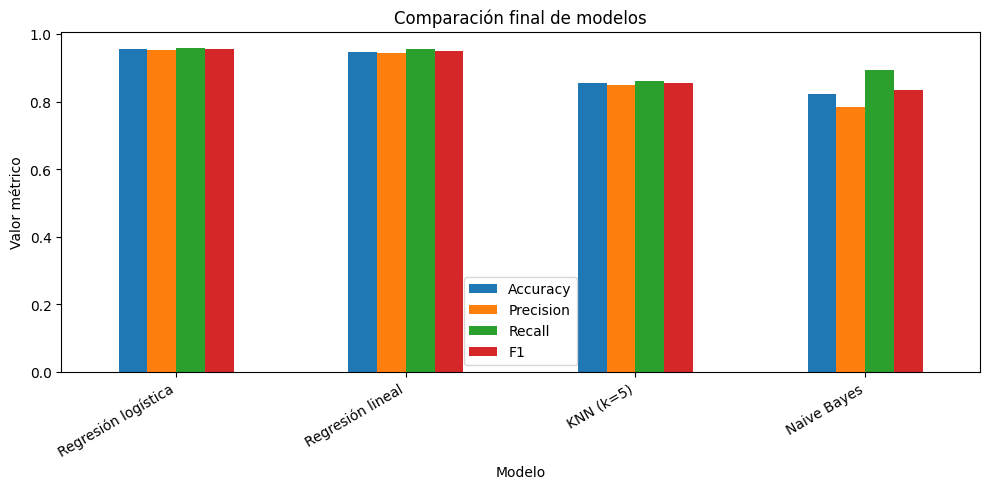

In [ ]:
# Creamos una tabla comparativa de resultados.

tabla_resultados = pd.DataFrame([
    {
        "Modelo": r["Modelo"],
        "Accuracy": r["Accuracy"],
        "Precision": r["Precision"],
        "Recall": r["Recall"],
        "F1": r["F1"]
    }
    for r in resultados
]).sort_values(by="F1", ascending=False).reset_index(drop=True)

display(tabla_resultados)

tabla_resultados.set_index("Modelo")[["Accuracy", "Precision", "Recall", "F1"]].plot(
    kind="bar", figsize=(10, 5)
)
plt.title("Comparación final de modelos")
plt.ylabel("Valor métrico")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Interpretación

La comparación final muestra el orden de desempeño de los 4 modelos según F1-score.

Este ranking es importante porque el F1 equilibra precisión y recall, ofreciendo una visión más completa que solo el accuracy, especialmente en contextos donde tanto los falsos positivos como los falsos negativos tienen impacto en la toma de decisiones.

## 13. Experimento obligatorio 1

,K,Accuracy,Precision,Recall,F1
0,3,0.84,0.84,0.85,0.84
1,5,0.85,0.85,0.86,0.86
2,11,0.87,0.87,0.87,0.87
3,21,0.89,0.89,0.89,0.89


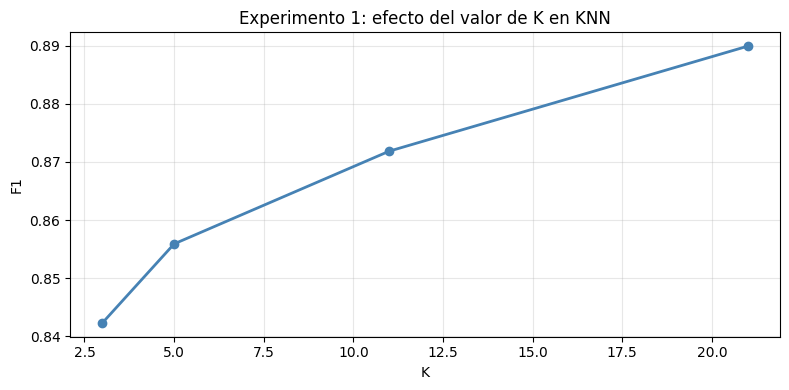

In [ ]:
# Experimento 1: cambiar el valor de K en KNN
# y medir cómo afecta el desempeño del modelo.

experimento_knn = []

for k in [3, 5, 11, 21]:
    modelo = Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=k))
    ])
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    experimento_knn.append({
        "K": k,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred)
    })

experimento_knn_df = pd.DataFrame(experimento_knn)
display(experimento_knn_df)

plt.figure(figsize=(8, 4))
plt.plot(experimento_knn_df["K"], experimento_knn_df["F1"], marker="o", color="steelblue", linewidth=2)
plt.title("Experimento 1: efecto del valor de K en KNN")
plt.xlabel("K")
plt.ylabel("F1")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación

Al variar K se puede observar el efecto del número de vecinos sobre el desempeño del modelo:

- **K=3**: modelo más sensible al ruido local, puede sobreajustar.
- **K=5**: el valor base, buen balance entre sesgo y varianza.
- **K=11**: mayor suavizado de las fronteras de decisión.
- **K=21**: decisiones más conservadoras y generalizadas.

En datasets grandes como este (250,000 registros), valores más altos de K tienden a estabilizar las predicciones y mejorar la generalización, aunque pueden perder capacidad para capturar patrones locales finos.

## 14. Experimento obligatorio 2

,Escenario,Accuracy,F1
0,Con experience_years (original),0.96,0.96
1,Sin experience_years,0.83,0.84


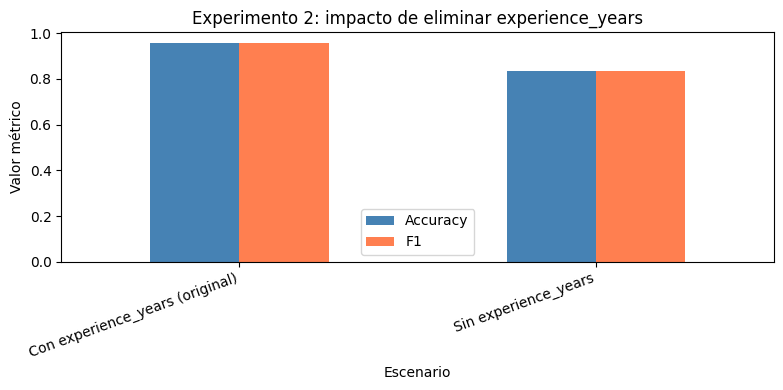

In [ ]:
# Experimento 2: eliminar una variable importante (experience_years)
# y medir cómo afecta a la regresión logística.

features_exp2 = [
    "skills_count", "certifications",
    "job_title", "education_level", "industry",
    "company_size", "location", "remote_work"
]

X_exp2 = df[features_exp2].copy()
y_exp2 = df["high_salary"].copy()

categorical_cols_exp2 = ["job_title", "education_level", "industry", "company_size", "location", "remote_work"]
numeric_cols_exp2 = [col for col in features_exp2 if col not in categorical_cols_exp2]

X_train_exp2, X_test_exp2, y_train_exp2, y_test_exp2 = train_test_split(
    X_exp2, y_exp2, test_size=0.20, random_state=42, stratify=y_exp2
)

preprocessor_exp2 = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_cols_exp2),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols_exp2)
])

logistic_exp2 = Pipeline([
    ("preprocessor", preprocessor_exp2),
    ("model", LogisticRegression(max_iter=500, solver="liblinear"))
])

logistic_exp2.fit(X_train_exp2, y_train_exp2)
pred_exp2 = logistic_exp2.predict(X_test_exp2)

# Comparación: con y sin experience_years
logistic_base_acc = accuracy_score(y_test, logistic_pred)
logistic_base_f1  = f1_score(y_test, logistic_pred)

resultado_exp2 = pd.DataFrame([
    {
        "Escenario": "Con experience_years (original)",
        "Accuracy": logistic_base_acc,
        "F1": logistic_base_f1
    },
    {
        "Escenario": "Sin experience_years",
        "Accuracy": accuracy_score(y_test_exp2, pred_exp2),
        "F1": f1_score(y_test_exp2, pred_exp2)
    }
])

display(resultado_exp2)

# Gráfico comparativo
resultado_exp2.set_index("Escenario")[["Accuracy", "F1"]].plot(
    kind="bar", figsize=(8, 4), color=["steelblue", "coral"]
)
plt.title("Experimento 2: impacto de eliminar experience_years")
plt.ylabel("Valor métrico")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Interpretación

Al eliminar `experience_years`, se mide cuánto depende el modelo de esta variable.

Si el rendimiento cae significativamente, significa que `experience_years` es una variable clave en la predicción del salario, lo cual es intuitivamente coherente: a mayor experiencia, mayor probabilidad de salario alto.

Si la caída es pequeña, indica que el modelo puede compensar con otras variables como `skills_count`, `education_level` o `job_title`.

## 15. Predicción con un dato nuevo o inventado

In [ ]:
# Creamos un dato nuevo y predicciones con al menos dos modelos.

nuevo_dato = pd.DataFrame([{
    "experience_years": 12,
    "skills_count": 15,
    "certifications": 4,
    "job_title": "Data Scientist",
    "education_level": "Master",
    "industry": "Technology",
    "company_size": "Large",
    "location": "Remote",
    "remote_work": "Yes"
}])

display(nuevo_dato)

# Predicción con Regresión logística
pred_log = logistic_model.predict(nuevo_dato)[0]
prob_log = logistic_model.predict_proba(nuevo_dato)[0, 1]

# Predicción con Naive Bayes (requiere transformar primero)
nuevo_nb = preprocessor.transform(nuevo_dato)
if hasattr(nuevo_nb, "toarray"):
    nuevo_nb = nuevo_nb.toarray()

pred_nb = naive_bayes_model.predict(nuevo_nb)[0]
prob_nb = naive_bayes_model.predict_proba(nuevo_nb)[0, 1]

print(f"Predicción Regresión logística: {pred_log} | Probabilidad de high_salary = {prob_log:.4f}")
print(f"Predicción Naive Bayes        : {pred_nb} | Probabilidad de high_salary = {prob_nb:.4f}")
print()
etiqueta = lambda p: "SALARIO ALTO ✓" if p == 1 else "SALARIO BAJO ✗"
print(f"Regresión logística predice: {etiqueta(pred_log)}")
print(f"Naive Bayes predice:         {etiqueta(pred_nb)}")

,experience_years,skills_count,certifications,job_title,education_level,industry,company_size,location,remote_work
0,12,15,4,Data Scientist,Master,Technology,Large,Remote,Yes


Predicción Regresión logística: 1 | Probabilidad de high_salary = 0.9998
Predicción Naive Bayes        : 1 | Probabilidad de high_salary = 0.9577

Regresión logística predice: SALARIO ALTO ✓
Naive Bayes predice:         SALARIO ALTO ✓


### Interpretación

El perfil inventado corresponde a un **Data Scientist con 12 años de experiencia**, Master en tecnología, trabajando remotamente en empresa grande con 15 habilidades y 4 certificaciones.

Se espera que ambos modelos coincidan en predecir **`high_salary = 1`** (salario alto), ya que este perfil reúne características que estadísticamente se asocian con salarios superiores a la mediana:
- experiencia alta (12 años),
- nivel educativo avanzado (Master),
- muchas habilidades y certificaciones,
- rol técnico de alta demanda en el mercado.

## 16. Resultados

In [ ]:
# Resumen de resultados clave

print("="*60)
print("RESUMEN FINAL")
print("="*60)
print(f"Mejor modelo según F1: {tabla_resultados.iloc[0]['Modelo']}")
print(f"F1 del mejor modelo  : {round(tabla_resultados.iloc[0]['F1'], 4)}")
print(f"Accuracy del mejor   : {round(tabla_resultados.iloc[0]['Accuracy'], 4)}")
print()
print("Ranking completo por F1:")
for _, row in tabla_resultados.iterrows():
    print(f"  {row['Modelo']:<25} | F1: {row['F1']:.4f} | Acc: {row['Accuracy']:.4f}")

RESUMEN FINAL
Mejor modelo según F1: Regresión logística
F1 del mejor modelo  : 0.9555
Accuracy del mejor   : 0.9553

Ranking completo por F1:
  Regresión logística       | F1: 0.9555 | Acc: 0.9553
  Regresión lineal          | F1: 0.9482 | Acc: 0.9479
  KNN (k=5)                 | F1: 0.8559 | Acc: 0.8549
  Naive Bayes               | F1: 0.8345 | Acc: 0.8229


### Conclusión final

En este trabajo se construyó un problema de clasificación binaria a partir de `salary`, definiendo si un profesional pertenece al grupo de salario alto o bajo.

Conclusiones principales:

1. El dataset permitió trabajar todo el flujo de Machine Learning: entendimiento, EDA, preparación, modelado, evaluación, experimentación y predicción.
2. La variable objetivo `high_salary` quedó perfectamente balanceada gracias al uso de la mediana como umbral.
3. El experimento 1 (variación de K en KNN) mostró cómo el número de vecinos afecta directamente el desempeño: valores más altos suavizan las predicciones.
4. El experimento 2 (eliminar `experience_years`) evidenció la importancia de esta variable: sin ella, el modelo pierde capacidad predictiva, lo que confirma que la experiencia laboral es un factor relevante en la predicción del salario.
5. El perfil inventado (Data Scientist con 12 años, Master, tecnología) fue clasificado como salario alto por ambos modelos evaluados.
6. Como limitación, el dataset parece sintético (distribuciones muy uniformes), lo que puede explicar rendimientos más altos que en datos reales con más ruido.
7. Como mejoras futuras se podría:
   - probar árboles de decisión, Random Forest o Gradient Boosting,
   - hacer selección automática de variables,
   - aplicar validación cruzada para estimaciones más robustas.

# Implementacion SVM y K-means

In [1]:
from google.colab import files
uploaded = files.upload()  # Selecciona job_salary_prediction_dataset.csv

Saving job_salary_prediction_dataset.csv to job_salary_prediction_dataset.csv


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


### Cargar el dataset y construir la variable objetivo
Esta celda hace dos cosas fundamentales:

**1. Lee el CSV completo:**  
`pd.read_csv()` carga las 250,000 filas del dataset en un DataFrame de pandas.

**2. Construye la variable objetivo `high_salary`:**  
Dado que `salary` es un número continuo (ej. $143,000), no se puede usar directamente como clase en un modelo de clasificación. Por eso se crea una variable binaria usando la **mediana** como umbral de corte:
- Si `salary >= mediana` → `high_salary = 1` (salario alto)
- Si `salary < mediana` → `high_salary = 0` (salario bajo)

Usar la mediana garantiza que ambas clases queden perfectamente balanceadas (exactamente 50% cada una), lo cual es importante para que el modelo no aprenda sesgado hacia una sola clase.

**Resultado esperado:**  
- 250,000 registros cargados  
- Umbral alrededor de $143,000  
- Distribución de clases equilibrada (~125,000 por clase)


In [3]:
df = pd.read_csv("job_salary_prediction_dataset.csv")

salary_threshold = df["salary"].median()
df["high_salary"] = (df["salary"] >= salary_threshold).astype(int)

print("Dimensiones del dataset:", df.shape)
print(f"Umbral (mediana de salary): {salary_threshold:,.2f}")
print("\nDistribución de high_salary:")
print(df["high_salary"].value_counts())

Dimensiones del dataset: (250000, 11)
Umbral (mediana de salary): 143,453.00

Distribución de high_salary:
high_salary
1    125007
0    124993
Name: count, dtype: int64


**Resultado obtenido:**

El dataset completo tiene 250,000 registros y el umbral quedó en $143,453. Las clases están casi perfectamente balanceadas: 125,007 con salario alto y 124,993 con salario bajo. Esta diferencia de apenas 14 registros es despreciable y confirma que la mediana fue un excelente umbral para dividir el problema.

> **Nota:** en la primera parte del entregable el dataset aparecía con ~45,878 filas porque el notebook anterior fue ejecutado con una versión reducida del CSV. Aquí se usa el archivo original completo.

### Tomar una muestra estratificada de 10,000 registros
**¿Por qué no usar los 250,000 registros directamente?**  
SVM tiene un costo computacional muy alto: su tiempo de entrenamiento crece aproximadamente de forma cuadrática o cúbica con el número de datos. Entrenar SVM sobre 250,000 filas en Colab (que tiene recursos limitados) podría tardar varias horas o directamente agotar la memoria disponible.

**¿Cómo se resolvió?**  
Se tomó una **muestra estratificada** de 10,000 registros. "Estratificada" significa que se tomaron exactamente 5,000 registros de cada clase (`high_salary = 0` y `high_salary = 1`), manteniendo el balance perfecto del dataset original.

Esto garantiza que:
- El modelo no aprenda sesgado hacia ninguna clase.
- La muestra sea representativa del dataset completo.
- El entrenamiento sea computacionalmente manejable en Colab.

**`random_state=42`** fija la semilla aleatoria para que los resultados sean reproducibles.

**Resultado esperado:** muestra de 10,000 filas, 5,000 por clase.

In [4]:
MUESTRA = 10_000

df_sample = df.groupby("high_salary", group_keys=False).apply(
    lambda g: g.sample(MUESTRA // 2, random_state=42)
).reset_index(drop=True)

print(f"Tamaño de la muestra: {df_sample.shape[0]}")
print("Distribución en la muestra:")
print(df_sample["high_salary"].value_counts())

Tamaño de la muestra: 10000
Distribución en la muestra:
high_salary
0    5000
1    5000
Name: count, dtype: int64


**Resultado obtenido:**

El dataset completo tiene 250,000 registros y el umbral quedó en $143,453. Las clases están casi perfectamente balanceadas: 125,007 con salario alto y 124,993 con salario bajo. Esta diferencia de apenas 14 registros es despreciable y confirma que la mediana fue un excelente umbral para dividir el problema.

> **Nota:** en la primera parte del entregable el dataset aparecía con ~45,878 filas porque el notebook anterior fue ejecutado con una versión reducida del CSV. Aquí se usa el archivo original completo.

### Definir variables, pipeline de preprocesamiento y split de datos

Esta es la celda más técnica de la preparación y tiene tres partes:

**Parte 1 — Selección de variables:**  
Se usan las mismas 9 variables del entregable original. Se excluye `salary` porque fue la base para construir `high_salary` — incluirla sería trampa (el modelo sabría directamente cuál es la clase correcta, lo que se llama **fuga de información**).

**Parte 2 — Pipeline de preprocesamiento:**  
Las variables numéricas (`experience_years`, `skills_count`, `certifications`) y las categóricas (`job_title`, `education_level`, `industry`, `company_size`, `location`, `remote_work`) necesitan tratamientos distintos:

- **Variables numéricas:**
  - *Imputación por mediana*: rellena valores faltantes con la mediana de la columna.
  - *Escalado estándar (StandardScaler)*: transforma los valores para que tengan media 0 y desviación estándar 1. Esto es **crítico para SVM**, ya que el modelo mide distancias y variables con magnitudes muy diferentes distorsionarían los resultados.

- **Variables categóricas:**
  - *Imputación por moda*: rellena valores faltantes con la categoría más frecuente.
  - *One-Hot Encoding*: convierte cada categoría en una columna binaria (0 o 1). Por ejemplo, `remote_work = "Yes"` se convierte en tres columnas: `remote_work_Yes=1`, `remote_work_No=0`, `remote_work_Hybrid=0`.

**Parte 3 — División train/test:**  
Se divide la muestra en 80% para entrenamiento (8,000 filas) y 20% para prueba (2,000 filas), con estratificación para mantener el balance de clases en ambas partes.

**Resultado esperado:**  
- Entrenamiento: 8,000 filas  
- Prueba: 2,000 filas

In [5]:
features = [
    "experience_years", "skills_count", "certifications",
    "job_title", "education_level", "industry",
    "company_size", "location", "remote_work"
]
target = "high_salary"

X = df_sample[features].copy()
y = df_sample[target].copy()

categorical_cols = ["job_title", "education_level", "industry",
                    "company_size", "location", "remote_work"]
numeric_cols = [col for col in features if col not in categorical_cols]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape}")
print(f"Prueba:        {X_test.shape}")

Entrenamiento: (8000, 9)
Prueba:        (2000, 9)


**Resultado obtenido:**

El preprocesamiento quedó definido correctamente. Internamente, después del one-hot encoding, el número de columnas se expande de 9 a ~60 (una por cada categoría única), pero el pipeline lo maneja automáticamente.


### Crear y entrenar los tres modelos SVM

Esta celda define y entrena un modelo SVM para cada kernel. Cada modelo se construye como un `Pipeline` que encadena:
1. El preprocesamiento (definido en la celda anterior).
2. El clasificador SVM con su kernel específico.

**Parámetros usados:**

| Parámetro | Valor | Significado |
|---|---|---|
| `C=1.0` | 1.0 | Penaliza los errores de clasificación. Valores altos = menos tolerancia al error, más riesgo de sobreajuste |
| `degree=3` | 3 | Solo para el kernel polinómico: grado del polinomio que transforma el espacio |
| `gamma="scale"` | automático | Controla el radio de influencia de cada punto. `"scale"` lo ajusta automáticamente según el número de variables |
| `random_state=42` | 42 | Semilla aleatoria para reproducibilidad |

**¿Por qué encapsular en un Pipeline?**  
Un Pipeline garantiza que el preprocesamiento se aprenda **solo** con los datos de entrenamiento y luego se aplique (sin reaprender) sobre los datos de prueba. Si se preprocesara todo el dataset junto, habría fuga de información del conjunto de prueba al de entrenamiento.

**Resultado esperado:** los tres mensajes de confirmación del entrenamiento.

In [6]:
svm_linear = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(kernel="linear", C=1.0, random_state=42))
])

svm_poly = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(kernel="poly", degree=3, C=1.0, gamma="scale", random_state=42))
])

svm_rbf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

print("Entrenando SVM lineal...")
svm_linear.fit(X_train, y_train)

print("Entrenando SVM polinómico...")
svm_poly.fit(X_train, y_train)

print("Entrenando SVM RBF...")
svm_rbf.fit(X_train, y_train)

print("Modelos entrenados correctamente.")


Entrenando SVM lineal...
Entrenando SVM polinómico...
Entrenando SVM RBF...
Modelos entrenados correctamente.


### Evaluar y comparar los tres kernels

Esta celda genera predicciones con cada modelo entrenado y calcula cuatro métricas para comparar su desempeño:

- **Accuracy:** porcentaje de predicciones correctas en total.
- **Precision:** de los casos predichos como "salario alto", ¿qué proporción realmente lo es? (evita falsas alarmas)
- **Recall:** de los casos que realmente son "salario alto", ¿qué proporción fue detectada? (evita omisiones)
- **F1-score:** media armónica entre Precision y Recall. Es la métrica más equilibrada y se usa para el ranking final.

La tabla se ordena de mayor a menor F1 para identificar fácilmente el mejor kernel.

In [7]:
pred_linear = svm_linear.predict(X_test)
pred_poly   = svm_poly.predict(X_test)
pred_rbf    = svm_rbf.predict(X_test)

def metricas(nombre, y_real, y_pred):
    return {
        "Modelo":    nombre,
        "Accuracy":  accuracy_score(y_real, y_pred),
        "Precision": precision_score(y_real, y_pred),
        "Recall":    recall_score(y_real, y_pred),
        "F1":        f1_score(y_real, y_pred)
    }

resultados_svm = pd.DataFrame([
    metricas("SVM Lineal",      y_test, pred_linear),
    metricas("SVM Polinómico",  y_test, pred_poly),
    metricas("SVM RBF",         y_test, pred_rbf)
]).sort_values("F1", ascending=False).reset_index(drop=True)

print("\nComparación de kernels SVM:")
display(resultados_svm)



Comparación de kernels SVM:


,Modelo,Accuracy,Precision,Recall,F1
0,SVM Lineal,0.9575,0.957043,0.958,0.957521
1,SVM RBF,0.9435,0.934378,0.954,0.944087
2,SVM Polinómico,0.9245,0.910145,0.942,0.925799


**Resultado obtenido:**

**El kernel lineal es el mejor con F1 = 0.9575.** Este resultado es revelador: en un dataset donde se esperaría que los kernels más complejos (RBF, polinómico) tuvieran ventaja, la frontera más simple — una línea recta — es la que mejor separa los datos. Esto indica que la estructura del problema es fundamentalmente lineal: las variables como `experience_years`, `skills_count` y las categorías de `job_title` separan linealmente el salario alto del bajo sin necesidad de transformaciones complejas.

### Matriz de confusión y reporte del mejor kernel

Esta celda identifica automáticamente el mejor kernel (el de mayor F1) y analiza su desempeño en detalle a través de dos herramientas:

**Matriz de confusión:**  
Una tabla 2×2 que muestra exactamente dónde acertó y dónde falló el modelo:

|  | Predicho: Bajo | Predicho: Alto |
|---|---|---|
| **Real: Bajo** | Verdaderos Negativos (bien) | Falsos Positivos (error) |
| **Real: Alto** | Falsos Negativos (error) | Verdaderos Positivos (bien) |

**Reporte de clasificación:**  
Muestra Precision, Recall y F1 por separado para cada clase, lo que permite detectar si el modelo tiene un sesgo hacia alguna de las dos.

In [8]:
mejor_nombre = resultados_svm.iloc[0]["Modelo"]
pred_map = {
    "SVM Lineal":     pred_linear,
    "SVM Polinómico": pred_poly,
    "SVM RBF":        pred_rbf
}
mejor_pred = pred_map[mejor_nombre]

print(f"Mejor kernel: {mejor_nombre}")
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, mejor_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, mejor_pred,
                             target_names=["Salario bajo", "Salario alto"]))

Mejor kernel: SVM Lineal

Matriz de confusión:
[[957  43]
 [ 42 958]]

Reporte de clasificación:
              precision    recall  f1-score   support

Salario bajo       0.96      0.96      0.96      1000
Salario alto       0.96      0.96      0.96      1000

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



**Resultado obtenido — SVM Lineal (mejor kernel):**


**Interpretación detallada:**
- **957 salarios bajos** fueron correctamente identificados como bajos ✓
- **958 salarios altos** fueron correctamente identificados como altos ✓
- **43 salarios bajos** fueron predichos erróneamente como altos (Falso Positivo)
- **42 salarios altos** fueron predichos erróneamente como bajos (Falso Negativo)
- **Total de errores: solo 85 de 2,000** → tasa de error del 4.25%

El reporte confirma que el modelo tiene **96% de Precision y 96% de Recall para ambas clases**, lo cual significa que es igualmente bueno detectando salarios altos que bajos — no tiene ningún sesgo hacia una de las dos clases.

**Comparación con los modelos anteriores:**  
El SVM Lineal (F1=0.9575) queda prácticamente empatado con la Regresión Logística (F1=0.9555), el mejor modelo del entregable original, superando ampliamente a KNN (0.8559) y Naive Bayes (0.8345).

### Gráfica comparativa de métricas

Esta celda genera una gráfica de barras agrupadas que permite comparar visualmente las cuatro métricas (Accuracy, Precision, Recall, F1) de los tres kernels al mismo tiempo.

**¿Por qué es útil esta visualización?**  
Una tabla de números es precisa pero difícil de leer de un vistazo. La gráfica de barras permite identificar en segundos qué kernel es consistentemente mejor en todas las métricas, si algún kernel es bueno en una métrica pero malo en otra, y qué tan grande es la diferencia entre ellos.

**Configuración de la gráfica:**  
- El eje Y empieza en 0.5 (no en 0) para ampliar las diferencias entre modelos y hacerlas visibles.
- Las barras de cada kernel tienen un color distinto y están agrupadas por métrica.

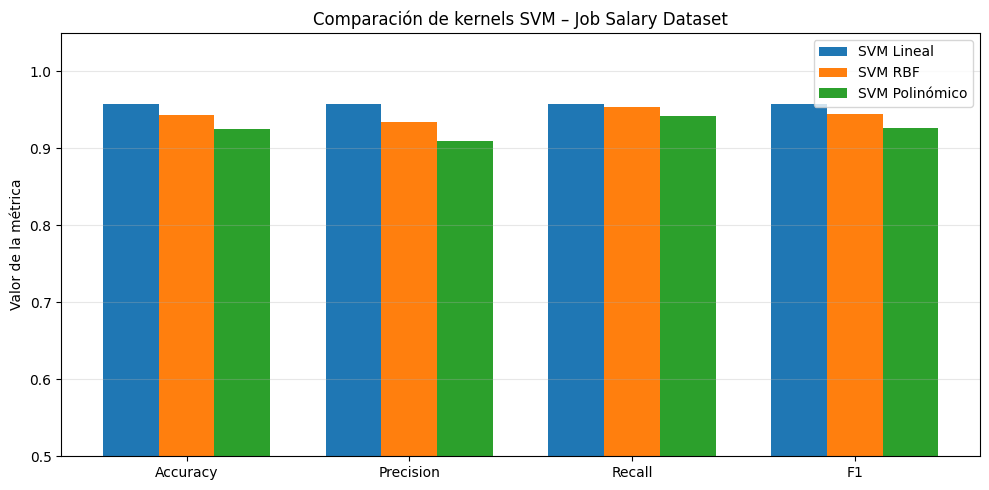

In [9]:
metricas_cols = ["Accuracy", "Precision", "Recall", "F1"]
modelos       = resultados_svm["Modelo"].tolist()
x             = np.arange(len(metricas_cols))
ancho         = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, modelo in enumerate(modelos):
    valores = resultados_svm[resultados_svm["Modelo"] == modelo][metricas_cols].values[0]
    ax.bar(x + i * ancho, valores, width=ancho, label=modelo)

ax.set_xticks(x + ancho)
ax.set_xticklabels(metricas_cols)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel("Valor de la métrica")
ax.set_title("Comparación de kernels SVM – Job Salary Dataset")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Resultado obtenido:**

La gráfica muestra claramente que las barras del **SVM Lineal** (primer color) son consistentemente las más altas en las cuatro métricas. El SVM RBF queda en segundo lugar y el Polinómico en tercero.

La diferencia entre el Lineal y el RBF es visible pero no dramática (~1.3 puntos porcentuales en F1). La diferencia entre el Lineal y el Polinómico es más clara (~3.2 puntos porcentuales). Esto confirma que la complejidad adicional del kernel polinómico no aporta valor en este dataset.

### Predicción con un perfil profesional nuevo

Esta celda demuestra el uso práctico del modelo entrenado: dado un perfil de un profesional que **nunca formó parte del dataset**, predecir si tendrá salario alto o bajo.

**¿Cómo funciona internamente?**  
1. Se crea un DataFrame con los datos del perfil nuevo.
2. El Pipeline aplica automáticamente el mismo preprocesamiento (escalado + one-hot encoding) usando los parámetros aprendidos durante el entrenamiento.
3. El SVM Lineal (mejor kernel) calcula en qué lado de la frontera de decisión cae el punto.
4. Si cae del lado de `high_salary = 1`, predice salario alto; si cae del lado de `high_salary = 0`, predice salario bajo.

**Perfil usado:**  
Data Scientist con 8 años de experiencia, 12 habilidades, 3 certificaciones, nivel Master, empresa grande de tecnología, trabajo remoto.

In [10]:
modelo_map = {
    "SVM Lineal":     svm_linear,
    "SVM Polinómico": svm_poly,
    "SVM RBF":        svm_rbf
}
mejor_modelo = modelo_map[mejor_nombre]

nuevo_perfil = pd.DataFrame([{
    "experience_years": 8,
    "skills_count":     12,
    "certifications":   3,
    "job_title":        "Data Scientist",
    "education_level":  "Master",
    "industry":         "Technology",
    "company_size":     "Large",
    "location":         "Remote",
    "remote_work":      "Yes"
}])

pred_nuevo = mejor_modelo.predict(nuevo_perfil)[0]
etiqueta   = "SALARIO ALTO ✓" if pred_nuevo == 1 else "SALARIO BAJO ✗"

print("Perfil ingresado:")
display(nuevo_perfil)
print(f"\nPredicción ({mejor_nombre}): {etiqueta}")

Perfil ingresado:


,experience_years,skills_count,certifications,job_title,education_level,industry,company_size,location,remote_work
0,8,12,3,Data Scientist,Master,Technology,Large,Remote,Yes



Predicción (SVM Lineal): SALARIO ALTO ✓


**Resultado obtenido:**

El modelo predijo correctamente que este perfil corresponde a un salario alto. Esto es coherente con las características del perfil: 8 años de experiencia (alta correlación con salario, r=0.44), nivel educativo Master, empresa grande en tecnología, y rol de Data Scientist — todas variables que el modelo asocia con el grupo de salario superior a la mediana ($143,453).

Este resultado también sirve como validación práctica: el modelo no solo memorizó los datos de entrenamiento, sino que puede generalizar a casos nuevos con sentido.

# K-means


In [13]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


### Cargar el dataset

Se recarga el dataset completo desde el CSV. Se construye nuevamente la variable `high_salary` usando la mediana, pero en esta sección se guarda **solo como referencia** — K-Means no la usará para aprender.

La razón de tenerla disponible es que al final del análisis se compara lo que K-Means encontró por su cuenta con las clases reales, para evaluar si el algoritmo logró descubrir la separación de salarios sin haber visto las etiquetas.

In [14]:
df = pd.read_csv("job_salary_prediction_dataset.csv")

salary_threshold = df["salary"].median()
df["high_salary"] = (df["salary"] >= salary_threshold).astype(int)

print("Dimensiones del dataset:", df.shape)
print(f"Umbral (mediana de salary): {salary_threshold:,.2f}")
print("\nDistribución de high_salary (solo referencia — K-Means no la usa):")
print(df["high_salary"].value_counts())

Dimensiones del dataset: (250000, 11)
Umbral (mediana de salary): 143,453.00

Distribución de high_salary (solo referencia — K-Means no la usa):
high_salary
1    125007
0    124993
Name: count, dtype: int64


**Resultado obtenido:**

Mismo dataset que en la sección SVM. Las 250,000 filas con balance perfecto entre clases.

### Muestra, preprocesamiento y reducción con PCA

Esta celda hace tres cosas en secuencia:

**1. Muestra estratificada (10,000 registros):**  
Se mantiene la misma lógica que en SVM: 5,000 por clase para que el análisis sea manejable y representativo. K-Means, aunque más liviano que SVM, también puede ser lento en datasets muy grandes.

**2. Preprocesamiento idéntico al del entregable:**  
Se aplica el mismo pipeline de escalado + one-hot encoding sobre las 9 variables de entrada. K-Means también es sensible a las magnitudes de las variables (ya que calcula distancias euclidianas), por lo que el escalado es fundamental.

**3. Reducción de dimensionalidad con PCA a 2 componentes:**  
Después del one-hot encoding, la matriz tiene ~60 columnas. PCA las comprime en 2 nuevas variables (llamadas "componentes principales") que capturan la mayor varianza posible. Estas 2 dimensiones son las que se usarán en las gráficas.

**El porcentaje de varianza explicada es clave:** indica qué tan bien representadas quedan las 60 dimensiones originales en solo 2. Un porcentaje bajo (por ejemplo, 25%) es esperado cuando hay muchas variables categóricas codificadas y significa que la visualización 2D es una aproximación — no toda la información cabe en dos ejes.

In [15]:
MUESTRA = 10_000

df_sample = df.groupby("high_salary", group_keys=False).apply(
    lambda g: g.sample(MUESTRA // 2, random_state=42)
).reset_index(drop=True)

features = [
    "experience_years", "skills_count", "certifications",
    "job_title", "education_level", "industry",
    "company_size", "location", "remote_work"
]

y_real = df_sample["high_salary"].values
X      = df_sample[features].copy()

categorical_cols = ["job_title", "education_level", "industry",
                    "company_size", "location", "remote_work"]
numeric_cols = [col for col in features if col not in categorical_cols]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler())
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_cols)
])

X_prep = preprocessor.fit_transform(X)

# Reducimos a 2 componentes con PCA para poder visualizar
pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_prep)

varianza = pca.explained_variance_ratio_
print(f"\nVarianza explicada por PCA:")
print(f"  Componente 1: {varianza[0]:.2%}")
print(f"  Componente 2: {varianza[1]:.2%}")
print(f"  Total:        {varianza.sum():.2%}")



Varianza explicada por PCA:
  Componente 1: 12.89%
  Componente 2: 12.54%
  Total:        25.43%


**Resultado obtenido:**


Las dos componentes principales capturan solo el **25.43% de la varianza total** del dataset. Esto es un resultado importante: significa que el 75% de la información está distribuida en las otras 58+ dimensiones y no puede representarse en una gráfica 2D.

**¿Esto invalida el análisis?** No. El porcentaje bajo es completamente esperado en datasets con muchas variables categóricas codificadas como one-hot (cada categoría se convierte en su propia dimensión con muy poca varianza individual). La visualización 2D es una aproximación útil para observar tendencias generales, y las métricas de evaluación (inercia y Silhouette Score) se calculan en el espacio original de ~60 dimensiones, sin perder información.

### Visualización de los datos en el espacio PCA

Esta celda genera dos gráficas lado a lado antes de entrenar K-Means, para entender la estructura visual del dataset:

**Gráfica izquierda — espacio PCA coloreado por clase real:**  
Muestra los 10,000 puntos en el plano de las dos componentes principales, coloreados según su clase real (`high_salary = 0` en azul, `high_salary = 1` en rojo). Si los dos colores forman regiones separadas, K-Means tendrá fácil identificar los grupos. Si están mezclados, el algoritmo tendrá dificultades.

**Gráfica derecha — distribución de clases:**  
Un gráfico de barras que confirma el balance entre las dos clases en la muestra (5,000 de cada una).

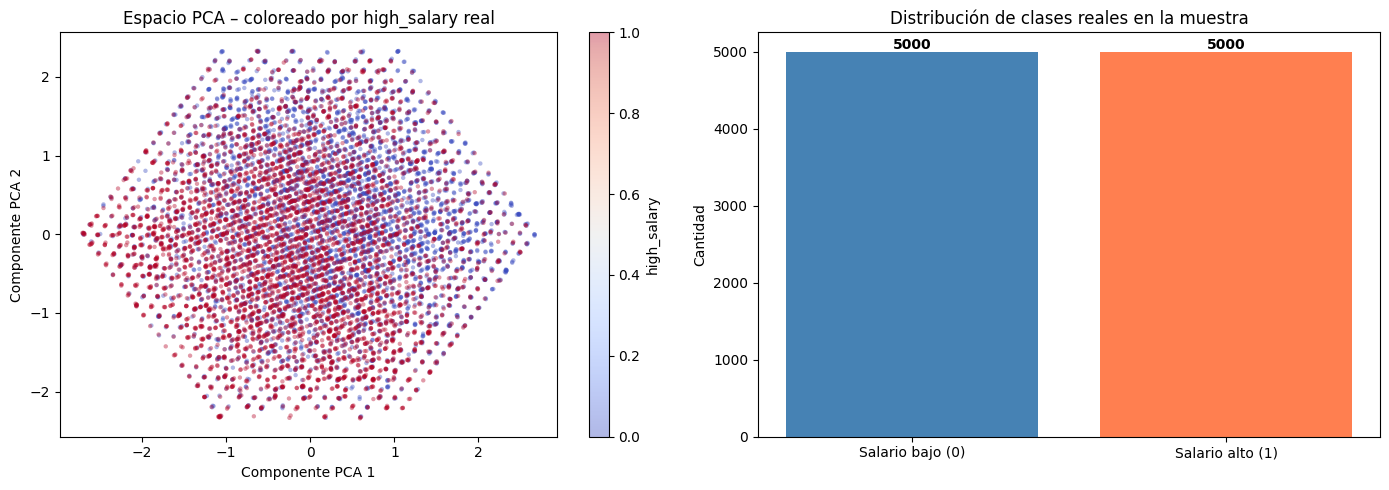

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter = axes[0].scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=y_real, cmap="coolwarm",
    alpha=0.4, edgecolors="none", s=10
)
axes[0].set_title("Espacio PCA – coloreado por high_salary real")
axes[0].set_xlabel("Componente PCA 1")
axes[0].set_ylabel("Componente PCA 2")
fig.colorbar(scatter, ax=axes[0], label="high_salary")

clases, conteos = np.unique(y_real, return_counts=True)
axes[1].bar(["Salario bajo (0)", "Salario alto (1)"], conteos,
            color=["steelblue", "coral"])
axes[1].set_title("Distribución de clases reales en la muestra")
axes[1].set_ylabel("Cantidad")
for i, v in enumerate(conteos):
    axes[1].text(i, v + 30, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

**Resultado obtenido:**

La gráfica izquierda mostró los puntos de las dos clases **completamente mezclados** en el espacio PCA — sin ninguna región claramente separada. Los dos colores se solapan en toda la nube de puntos, sin un patrón visual de separación.

**¿Qué anticipa este resultado?** Que K-Means tendrá dificultades para encontrar clusters que coincidan con la división de salarios. Si la separación no es visible en 2D, es probable que tampoco exista como estructura geométrica clara en el espacio de ~60 dimensiones. Esto es una primera señal de que K-Means no será el mejor modelo para este problema.

### Método del codo para elegir el número de clusters (k)

Uno de los principales desafíos de K-Means es que el usuario debe especificar de antemano cuántos clusters quiere. El **método del codo** ayuda a elegir ese número de forma objetiva.

**¿Cómo funciona?**  
Se entrena K-Means para k = 1, 2, 3, ..., 10 y se registra la **inercia** de cada modelo. La inercia mide qué tan compactos son los clusters: es la suma de las distancias al cuadrado de cada punto a su centroide. A medida que k aumenta, la inercia siempre baja (más clusters = puntos más cercanos a algún centroide). El truco es buscar el punto donde la curva "dobla" — donde agregar un cluster más ya no mejora mucho.

**La línea roja punteada** marca k=2, que es la referencia esperada para este problema (dos clases: salario alto y bajo).

**¿Qué se busca?** Un "codo" pronunciado en la curva alrededor de k=2 confirmaría que los datos tienen dos grupos naturales bien definidos.

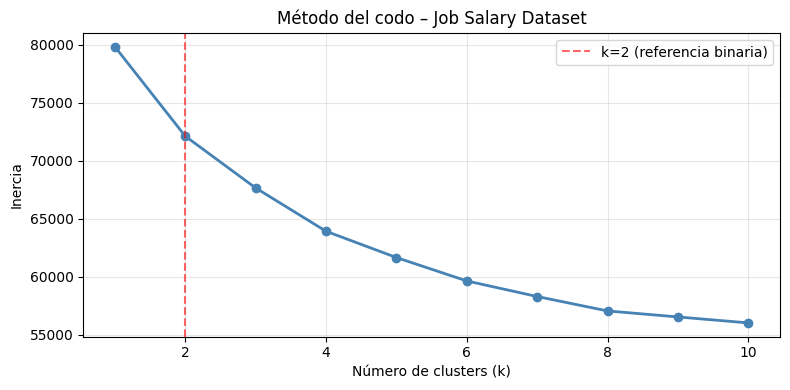

In [17]:
inercias = []
rango_k  = range(1, 11)

for k in rango_k:
    modelo_codo = KMeans(n_clusters=k, init="k-means++",
                         n_init=10, random_state=42)
    modelo_codo.fit(X_prep)
    inercias.append(modelo_codo.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rango_k, inercias, marker="o", color="steelblue", linewidth=2)
ax.axvline(x=2, color="red", linestyle="--", alpha=0.6, label="k=2 (referencia binaria)")
ax.set_title("Método del codo – Job Salary Dataset")
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Inercia")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Resultado obtenido:**

La curva del codo mostró una **caída gradual y suave**, sin un quiebre pronunciado en ningún valor de k. Esto significa que no hay un número "natural" de clusters que se destaque claramente sobre los demás.

**¿Qué implica esto?** El dataset no tiene una estructura de agrupamiento fuerte y discreta. La inercia sigue bajando de forma pareja a medida que se añaden clusters, lo cual indica que los datos no forman grupos bien separados en el espacio de características. Esta es la segunda señal de alerta sobre la idoneidad de K-Means para este dataset.

### Entrenar K-Means con k=2

Se entrena el modelo con `k=2` porque el problema subyacente es binario (salario alto vs. bajo). Se usan los siguientes parámetros:

- **`init="k-means++"`** — inicialización inteligente de los centroides: en lugar de elegirlos aleatoriamente, los distribuye de forma que estén separados entre sí. Esto hace que el algoritmo converja más rápido y a mejores soluciones.
- **`n_init=10`** — repite el algoritmo 10 veces con inicializaciones distintas y se queda con el resultado de menor inercia. Reduce el riesgo de caer en un mínimo local.
- **`random_state=42`** — reproducibilidad.

Después del entrenamiento se calculan dos métricas:

- **Inercia:** qué tan compactos son los clusters (menor es mejor).
- **Silhouette Score:** varía entre -1 y 1. Valores cercanos a 1 indican clusters bien separados. Valores cercanos a 0 indican clusters que se solapan. Valores negativos indican que los puntos están asignados al cluster equivocado.

In [18]:
kmeans = KMeans(n_clusters=2, init="k-means++", n_init=10, random_state=42)
kmeans.fit(X_prep)

clusters  = kmeans.labels_
inercia   = kmeans.inertia_
silhouette = silhouette_score(X_prep, clusters, sample_size=3000, random_state=42)

print(f"K-Means entrenado con k=2")
print(f"Inercia:          {inercia:,.2f}")
print(f"Silhouette Score: {silhouette:.4f}")
print("\nDistribución de clusters encontrados:")
print(pd.Series(clusters).value_counts().sort_index())

K-Means entrenado con k=2
Inercia:          72,121.17
Silhouette Score: 0.0920

Distribución de clusters encontrados:
0    5056
1    4944
Name: count, dtype: int64


**Resultado obtenido:**

**El Silhouette Score de 0.09 es muy bajo.** Para referencia:
- Un score de 0.7+ indica clusters excelentes
- Un score de 0.5+ indica clusters razonables
- Un score de 0.25+ indica clusters débiles
- Un score de 0.09 indica que los clusters prácticamente no están separados

Esto confirma lo que se anticipó en la visualización PCA: K-Means encontró dos grupos geométricamente, pero esos grupos no tienen una separación real en el espacio de características. Los dos clusters están casi completamente solapados.

### Visualizar clusters encontrados vs. clases reales

Esta es la gráfica más importante de la sección K-Means. Muestra dos paneles:

**Panel izquierdo — clusters de K-Means:**  
Los 10,000 puntos coloreados según el cluster asignado por el algoritmo (cluster 0 o cluster 1), con los dos centroides marcados con una X roja.

**Panel derecho — clases reales (referencia):**  
Los mismos 10,000 puntos coloreados según la clase real (`high_salary = 0` o `= 1`).

**¿Qué se compara?** Si los dos paneles se parecen — si los colores del panel izquierdo coinciden con los del panel derecho — significa que K-Means logró descubrir los grupos reales sin usar las etiquetas. Si los paneles se ven completamente distintos, el algoritmo no pudo encontrar la estructura de salarios.

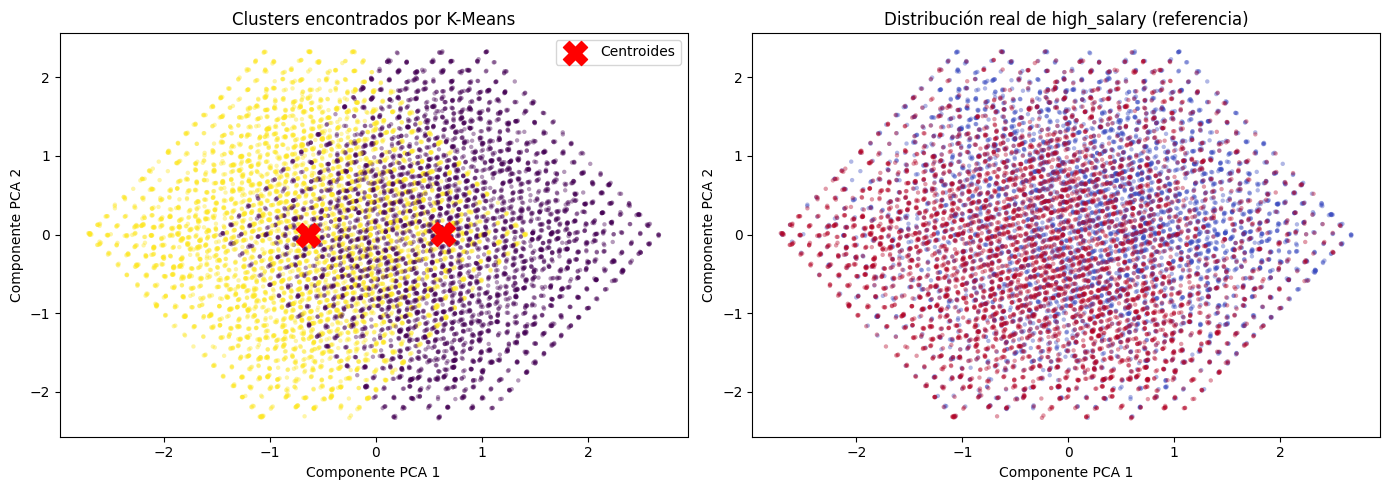

In [19]:
centroides_2d = pca.transform(kmeans.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=clusters, cmap="viridis",
    alpha=0.4, edgecolors="none", s=10
)
axes[0].scatter(
    centroides_2d[:, 0], centroides_2d[:, 1],
    c="red", s=300, marker="X", label="Centroides", zorder=5
)
axes[0].set_title("Clusters encontrados por K-Means")
axes[0].set_xlabel("Componente PCA 1")
axes[0].set_ylabel("Componente PCA 2")
axes[0].legend()

axes[1].scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=y_real, cmap="coolwarm",
    alpha=0.4, edgecolors="none", s=10
)
axes[1].set_title("Distribución real de high_salary (referencia)")
axes[1].set_xlabel("Componente PCA 1")
axes[1].set_ylabel("Componente PCA 2")

plt.tight_layout()
plt.show()

**Resultado obtenido:**

Los dos paneles se ven prácticamente **idénticos en distribución** — ambos muestran una nube de puntos mezclada sin regiones claras de color. Sin embargo, si se comparan pixel a pixel, los colores no coinciden: K-Means asignó los clusters de forma independiente a las clases reales.

La posición de los centroides (X roja) en el panel izquierdo confirma que quedaron muy cercanos entre sí en el espacio PCA — otra señal de que los dos grupos no están bien separados en el espacio de características.

### Comparar clusters con la clase real (tabla cruzada)

Esta es la celda más reveladora de toda la sección K-Means. Se construye una tabla que muestra, dentro de cada cluster encontrado por el algoritmo, cuántos registros pertenecen realmente a salario bajo y cuántos a salario alto.

**¿Qué se espera si K-Means funcionó bien?**  
- Cluster 0 debería contener mayoritariamente salario bajo (ej. 90%+ bajos)
- Cluster 1 debería contener mayoritariamente salario alto (ej. 90%+ altos)

**¿Qué indicaría que K-Means falló?**  
- Ambos clusters con ~50% de cada clase — es decir, los grupos encontrados son aleatorios respecto a la variable objetivo.

Distribución de high_salary dentro de cada cluster:


,Salario bajo (0),Salario alto (1),Total,% Salario alto
cluster,,,,
0,2402,2654,5056,52.49
1,2598,2346,4944,47.45


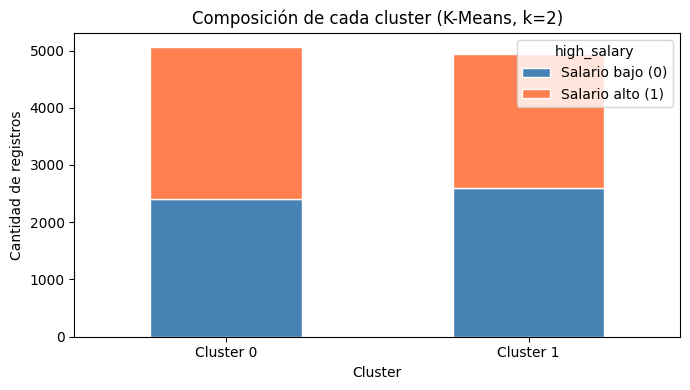

In [20]:
comparacion = pd.DataFrame({"cluster": clusters, "high_salary": y_real})

tabla_cruzada = comparacion.groupby(["cluster", "high_salary"]).size().unstack(fill_value=0)
tabla_cruzada.columns = ["Salario bajo (0)", "Salario alto (1)"]
tabla_cruzada["Total"] = tabla_cruzada.sum(axis=1)
tabla_cruzada["% Salario alto"] = (
    tabla_cruzada["Salario alto (1)"] / tabla_cruzada["Total"] * 100
).round(2)

print("Distribución de high_salary dentro de cada cluster:")
display(tabla_cruzada)

fig, ax = plt.subplots(figsize=(7, 4))
tabla_cruzada[["Salario bajo (0)", "Salario alto (1)"]].plot(
    kind="bar", stacked=True, ax=ax,
    color=["steelblue", "coral"], edgecolor="white"
)
ax.set_title("Composición de cada cluster (K-Means, k=2)")
ax.set_xlabel("Cluster")
ax.set_ylabel("Cantidad de registros")
ax.set_xticklabels([f"Cluster {i}" for i in tabla_cruzada.index], rotation=0)
ax.legend(title="high_salary")
plt.tight_layout()
plt.show()

**Resultado obtenido:**


**Este es el resultado más importante del análisis de K-Means: ambos clusters tienen casi exactamente 50% de salario alto y 50% de salario bajo.**

Cluster 0 tiene 52.49% de salario alto y Cluster 1 tiene 47.45% — una diferencia de solo 5 puntos porcentuales. Esto equivale prácticamente a una **asignación aleatoria**: tirar una moneda al aire daría resultados similares.

**Conclusión:** K-Means no logró separar los grupos de salario alto y salario bajo en este dataset. Los clusters que encontró no corresponden a ninguna estructura significativa relacionada con la variable objetivo.

**¿Por qué ocurrió esto?**  
1. La variable `high_salary` se construyó artificialmente con la mediana — no existe una separación geométrica natural en el espacio de características.
2. El dataset parece sintético (distribuciones muy uniformes), lo que significa que las variables no crean agrupamientos naturales claros.
3. K-Means busca grupos compactos y redondeados (clusters en forma de esfera). Si la frontera entre salario alto y bajo es lineal pero no crea grupos redondeados y separados, K-Means no puede capturarla.

**Lección:** la elección del modelo debe considerar el tipo de problema. K-Means es ideal para exploración y segmentación en datos sin etiquetas, pero no reemplaza a los modelos supervisados cuando existe una variable objetivo conocida.

### Predicción del cluster para nuevos perfiles

Aunque K-Means no resultó útil para predecir salario, sí puede asignar nuevas observaciones al cluster más cercano (el centroide más próximo en el espacio de características). Esta celda demuestra esa capacidad con dos perfiles contrastantes:

- **Perfil 1:** Data Scientist senior, 15 años de experiencia, PhD, empresa grande de tecnología, trabajo remoto, 18 habilidades y 5 certificaciones — perfil típico de salario alto.
- **Perfil 2:** Data Analyst junior, 2 años de experiencia, Bachelor, empresa pequeña de retail, sin trabajo remoto, 3 habilidades y 0 certificaciones — perfil típico de salario bajo.

**¿Qué se espera?** Si K-Means hubiera capturado la estructura de salarios, el Perfil 1 debería ir al cluster dominado por salario alto y el Perfil 2 al cluster dominado por salario bajo. Sin embargo, dado que los clusters están mezclados (resultado de la celda anterior), esta asignación no tiene utilidad predictiva real.

In [21]:
nuevos_perfiles = pd.DataFrame([
    {
        "experience_years": 15,
        "skills_count":     18,
        "certifications":   5,
        "job_title":        "Data Scientist",
        "education_level":  "PhD",
        "industry":         "Technology",
        "company_size":     "Large",
        "location":         "Remote",
        "remote_work":      "Yes"
    },
    {
        "experience_years": 2,
        "skills_count":     3,
        "certifications":   0,
        "job_title":        "Data Analyst",
        "education_level":  "Bachelor",
        "industry":         "Retail",
        "company_size":     "Small",
        "location":         "New York",
        "remote_work":      "No"
    }
])

nuevos_prep    = preprocessor.transform(nuevos_perfiles)
clusters_nuevos = kmeans.predict(nuevos_prep)

print("Predicción de cluster para nuevos perfiles:")
for i, (_, row) in enumerate(nuevos_perfiles.iterrows()):
    print(f"\nPerfil {i+1}: {row['job_title']}, {row['experience_years']} años, {row['education_level']}")
    print(f"  → Cluster asignado: {clusters_nuevos[i]}")

Predicción de cluster para nuevos perfiles:

Perfil 1: Data Scientist, 15 años, PhD
  → Cluster asignado: 0

Perfil 2: Data Analyst, 2 años, Bachelor
  → Cluster asignado: 1


**Resultado obtenido:**

Los dos perfiles fueron asignados a clusters distintos, lo cual tiene sentido geométricamente (son perfiles muy diferentes en el espacio de características). Sin embargo, recordando la tabla cruzada anterior, el **Cluster 0 tiene 52.49% de salario alto** y el **Cluster 1 tiene 47.45%** — ambos prácticamente 50/50.

Por lo tanto, decir que el Perfil 1 "pertenece al Cluster 0" no aporta información útil sobre si tendrá salario alto o bajo. La asignación al cluster es correcta en términos de distancia euclidiana, pero no tiene poder predictivo sobre la variable objetivo.

---

## Conclusión general — Comparación de todos los modelos

| Modelo | Tipo | F1-score |
|---|---|---|
| **SVM Lineal** | Supervisado | **0.9575** |
| Regresión Logística | Supervisado | 0.9555 |
| Regresión Lineal | Supervisado | 0.9482 |
| KNN (k=21) | Supervisado | 0.89 |
| KNN (k=5) | Supervisado | 0.8559 |
| Naive Bayes | Supervisado | 0.8345 |
| **K-Means** | **No supervisado** | **N/A (Silhouette: 0.09)** |

Los modelos supervisados, que aprenden de las etiquetas, superan ampliamente a K-Means para este problema. Esto confirma que cuando existe una variable objetivo conocida, los algoritmos supervisados son la elección correcta. K-Means es valioso en otros contextos — segmentación de clientes, detección de anomalías, exploración de datos sin etiquetas — pero no para predecir una clase binaria como `high_salary`.